# AI translation validation for Ubuntu - Model experiments
Romain Darous <br><br>
Exploration with the HuggingFace model sentence-transformers/distiluse-base-multilingual-cased-v2

## Importing relevant modules

In [7]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
from sentence_transformers import SentenceTransformer

ModuleNotFoundError: No module named 'sentence_transformers'

## Loading a data sample for experimenting

In [6]:
# Loading the data
data_path = '..\\2_data_processing\\tmp\\dataset\\debian\\debian-edu-documentation-fr.csv'
df = pd.read_csv(data_path, sep='|')
en = list(df['en'][:50])
fr = list(df['fr'][:50])

## Loading the multilingual sentence embedding model

In [7]:
model = SentenceTransformer('sentence-transformers/distiluse-base-multilingual-cased-v2')

# Computing the embeddings of the dataset
en_embeddings = model.encode(en)
fr_embeddings = model.encode(fr)

c:\Users\romai\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


### More advanced model loading
Trying to made the model work in a way that allows fine-tuning or pooling modification

In [1]:
from transformers import AutoTokenizer, AutoModel
import torch


#Mean Pooling - Take attention mask into account for correct averaging
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0] #First element of model_output contains all token embeddings
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)


# Sentences we want sentence embeddings for
sentences = ['This is an example sentence', 'Each sentence is converted']

# Load model from HuggingFace Hub
tokenizer = AutoTokenizer.from_pretrained('sentence-transformers/distiluse-base-multilingual-cased-v2')
model = AutoModel.from_pretrained('sentence-transformers/distiluse-base-multilingual-cased-v2')

# Tokenize sentences
encoded_input = tokenizer(sentences, padding=True, truncation=True, return_tensors='pt')

# Compute token embeddings
with torch.no_grad():
    model_output = model(**encoded_input)

# Perform pooling. In this case, max pooling.
sentence_embeddings = mean_pooling(model_output, encoded_input['attention_mask'])

print("Sentence embeddings:")
print(sentence_embeddings)




c:\Users\Romain Darous\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Romain Darous\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:147: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Romain Darous\.cache\huggingface\hub\models--sentence-transformers--distiluse-base-multilingual-cased-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you eit

Sentence embeddings:
tensor([[ 0.0789,  0.0301, -0.1049,  ...,  0.0582,  0.0896, -0.0407],
        [ 0.0042,  0.0390, -0.0065,  ...,  0.0326, -0.0006, -0.0060]])


## Comparing embeddings
The easiest way to compare two vectors is to use cosine similarity

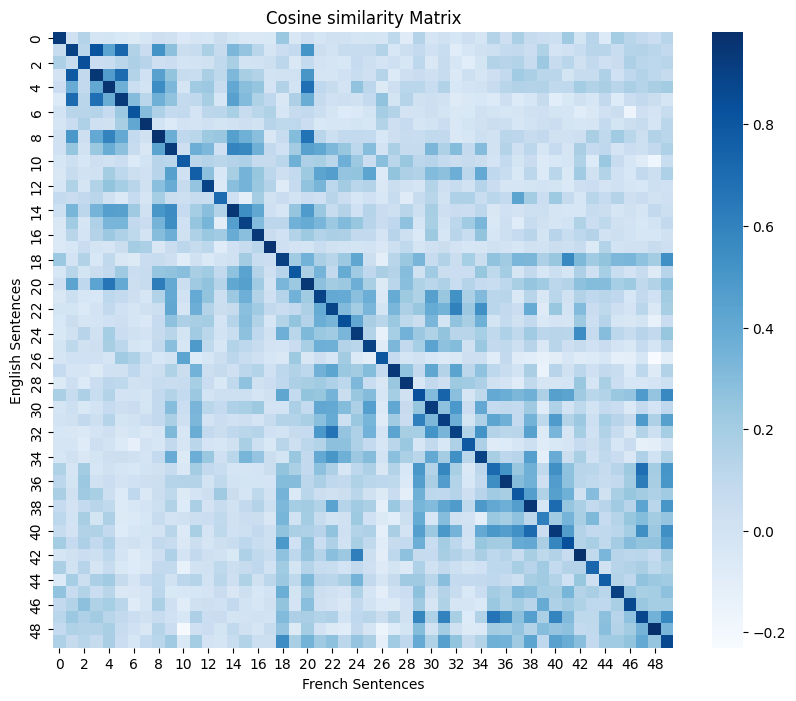

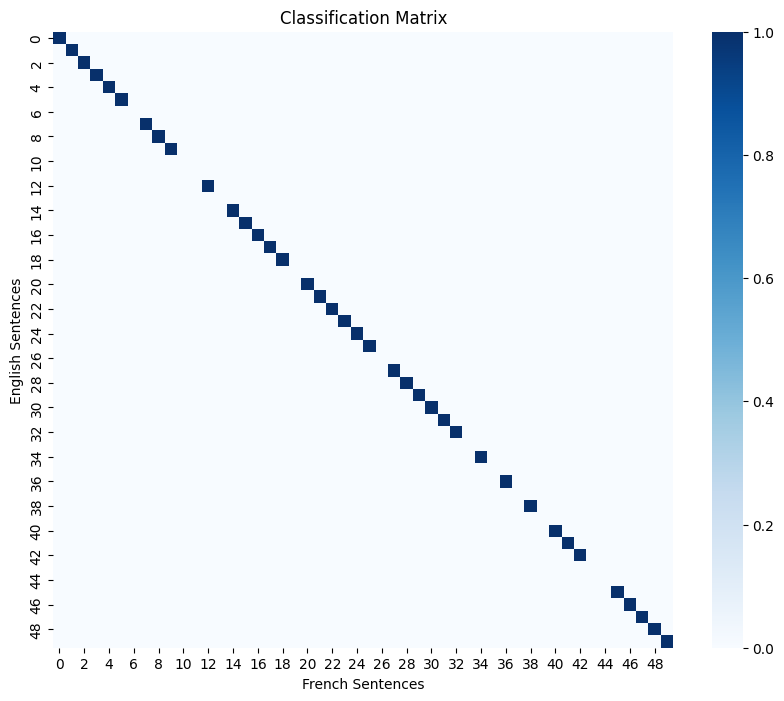

In [19]:
# Calculate cosine similarity
cosine_similarities = cosine_similarity(en_embeddings, fr_embeddings)


# Create a threshold matrix
threshold = 0.83
confusion_matrix = np.array([[1 if sim > threshold else 0 for sim in cos_sim] for cos_sim in cosine_similarities])

# Plot the threshold matrix and the cosine similarity matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cosine_similarities, annot=False, cmap='Blues', cbar=True)
plt.xlabel('French Sentences')
plt.ylabel('English Sentences')
plt.title('Cosine similarity Matrix')
plt.show()

# Plot the threshold matrix and the cosine similarity matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix, annot=False, cmap='Blues', cbar=True)
plt.xlabel('French Sentences')
plt.ylabel('English Sentences')
plt.title('Classification Matrix')
plt.show()
